### **Step 1: Load libraries and dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 61)
pd.set_option("display.width", 120)
sns.set(style="whitegrid", palette="muted")

In [3]:
file_path = r"C:\Users\Christopher\Documents\Python Projects\Online_News_Popularity\OnlineNewsPopularity.csv"
df = pd.read_csv(file_path)
print(f"Shape of the dataset is {df.shape}")
df.head(10)

Shape of the dataset is (39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,496.0,496.0,496.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,918.0,918.0,918.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028573,0.419300,0.494651,0.028905,0.028572,0.429850,0.100705,0.041431,0.020716,0.666667,0.333333,0.385965,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,545.0,16000.0,3151.157895,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028633,0.028794,0.028575,0.028572,0.885427,0.513502,0.281003,0.074627,0.012127,0.860215,0.139785,0.411127,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505
5,http://mashable.com/2013/01/07/beewi-smart-toys/,731.0,10.0,370.0,0.559889,1.0,0.698198,2.0,2.0,0.0,0.0,4.359459,9.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8500.0,8500.0,8500.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022245,0.306718,0.022231,0.022224,0.626582,0.437409,0.071184,0.029730,0.027027,0.523810,0.476190,0.350610,0.136364,0.6,-0.195000,-0.400,-0.100000,0.642857,0.214286,0.142857,0.214286,855
6,http://mashable.com/2013/01/07/bodymedia-armba...,731.0,8.0,960.0,0.418163,1.0,0.549834,21.0,20.0,20.0,0.0,4.654167,10.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,545.0,16000.0,3151.157895,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.020082,0.114705,0.020024,0.020015,0.825173,0.514480,0.268303,0.080208,0.016667,0.827957,0.172043,0.402039,0.100000,1.0,-0.224479,-0.500,-0.050000,0.000000,0.000000,

## **Step 2: Inspect dataset structure**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [6]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
timedelta,39644.0,354.530471,214.163767,8.0,164.000000,339.000000,542.000000,731.0
n_tokens_title,39644.0,10.398749,2.114037,2.0,9.000000,10.000000,12.000000,23.0
n_tokens_content,39644.0,546.514731,471.107508,0.0,246.000000,409.000000,716.000000,8474.0
n_unique_tokens,39644.0,0.548216,3.520708,0.0,0.470870,0.539226,0.608696,701.0
n_non_stop_words,39644.0,0.996469,5.231231,0.0,1.000000,1.000000,1.000000,1042.0
n_non_stop_unique_tokens,39644.0,0.689175,3.264816,0.0,0.625739,0.690476,0.754630,650.0
num_hrefs,39644.0,10.883690,11.332017,0.0,4.000000,8.000000,14.000000,304.0
num_self_hrefs,39644.0,3.293638,3.855141,0.0,1.000000,3.000000,4.000000,116.0
num_imgs,39644.0,4.544143,8.309434,0.0,1.000000,1.000000,4.000000,128.0
num_videos,39644.0,1.249874,4.107855,0.0,0.000000,0.000000,1.000000,91.0


### **Step 3: Targer variable (`shares`)**

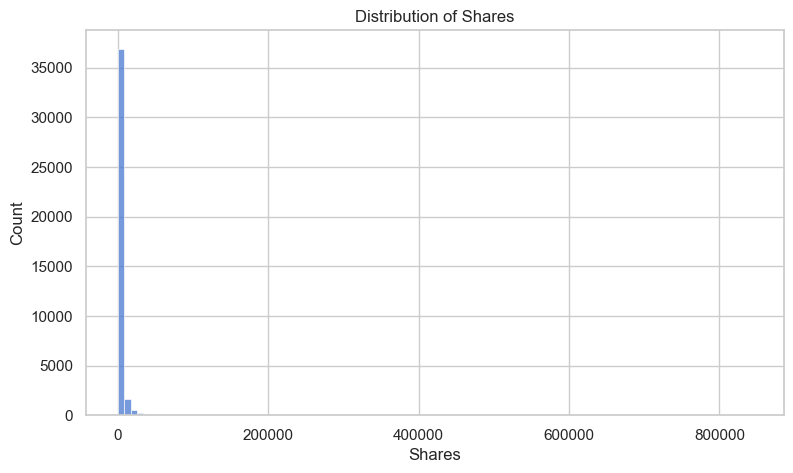

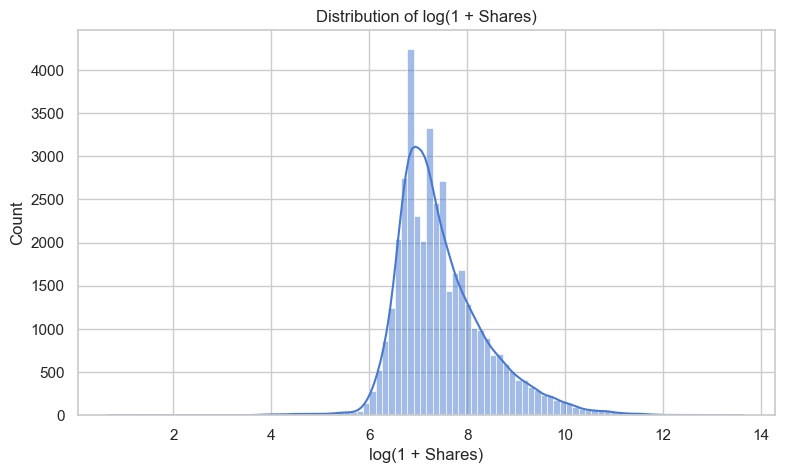

In [8]:
df.columns = df.columns.str.strip()
df['shares'].describe()

plt.figure(figsize=(9,5))
sns.histplot(df["shares"], bins=100, kde=False)
plt.title("Distribution of Shares")
plt.xlabel("Shares")
plt.ylabel("Count")
plt.show()

# Log-transform for skew
plt.figure(figsize=(9,5))
sns.histplot(np.log1p(df["shares"]), bins=100, kde=True)
plt.title("Distribution of log(1 + Shares)")
plt.xlabel("log(1 + Shares)")
plt.ylabel("Count")
plt.show()


Raw shares are very skewed, with most articles under a few thousand and a small number way higher. On a linear scale, the few viral articles stretch the axis, so the histogram collapses into a few bars. A log-transform rescales shares so the distribution is more balanced and easier to compare. That’s why editorial analytics almost always works with log-shares rather than raw shares.

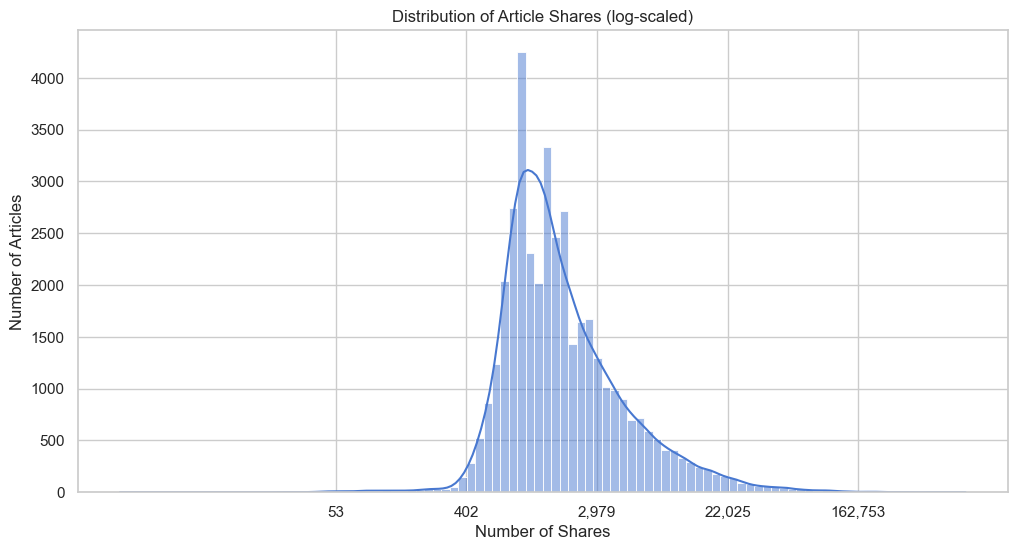

In [10]:
plt.figure(figsize=(12,6))
sns.histplot(np.log1p(df["shares"]), bins=100, kde=True)

# Better labels
plt.title("Distribution of Article Shares (log-scaled)")
plt.xlabel("Number of Shares")
plt.ylabel("Number of Articles")

# Replace log ticks with raw share numbers
ticks = [4, 6, 8, 10, 12]  # log values
labels = [f"{int(np.expm1(tick)):,}" for tick in ticks]  # back-transform to raw shares
plt.xticks(ticks, labels)

plt.show()


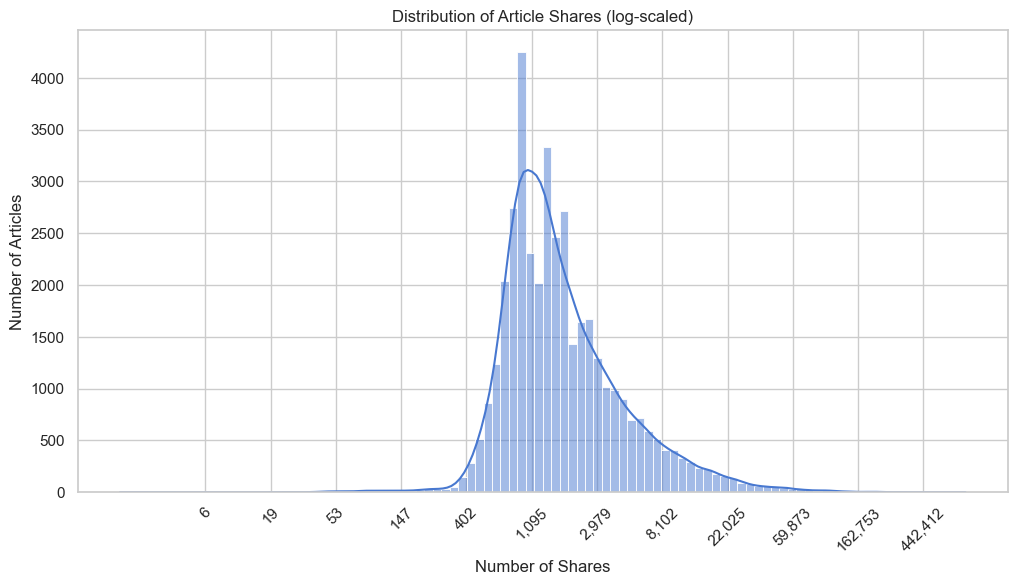

In [11]:
plt.figure(figsize=(12,6))
sns.histplot(np.log1p(df["shares"]), bins=100, kde=True)

plt.title("Distribution of Article Shares (log-scaled)")
plt.xlabel("Number of Shares")
plt.ylabel("Number of Articles")

# Choose more tick positions (log values)
ticks = np.arange(2, 14, 1)  # from 4 to 12, step = 1
labels = [f"{int(np.expm1(tick)):,}" for tick in ticks]  # back-transform

plt.xticks(ticks, labels, rotation=45)  # rotate to avoid overlap
plt.show()


In [12]:
import numpy as np

def articles_near_share(df, share_value, bins=100):
    """
    Given a share count, return its log1p value and
    the number of articles in the same histogram bin.
    """
    log_val = np.log1p(share_value)

    # Create histogram bins on log scale
    counts, bin_edges = np.histogram(np.log1p(df["shares"]), bins=bins)

    # Find which bin the log_val falls into
    bin_idx = np.digitize(log_val, bin_edges) - 1

    # Guard against edge cases
    if bin_idx < 0 or bin_idx >= len(counts):
        return log_val, 0, (None, None)

    # Bin range (low, high) for reference
    bin_range = (bin_edges[bin_idx], bin_edges[bin_idx+1])
    return log_val, counts[bin_idx], bin_range


In [13]:
log_val, count, bin_range = articles_near_share(df, 2000, bins=100)
print(f"log1p(2000) = {log_val:.2f}")
print(f"Articles in this bin: {count}")
print(f"Bin covers log range {bin_range[0]:.2f} – {bin_range[1]:.2f}")


log1p(2000) = 7.60
Articles in this bin: 1435
Bin covers log range 7.56 – 7.69


### **Step 4: Missing values + duplicates**

In [15]:
# Temporarily disable truncation
pd.set_option("display.max_rows", None)

missing_values = df.isna().sum().sort_values(ascending=False)
print(missing_values)

# Reset to default (so later outputs don’t spam your screen)
pd.reset_option("display.max_rows")


url                              0
weekday_is_monday                0
weekday_is_wednesday             0
weekday_is_thursday              0
weekday_is_friday                0
weekday_is_saturday              0
weekday_is_sunday                0
is_weekend                       0
LDA_00                           0
LDA_01                           0
LDA_02                           0
LDA_03                           0
LDA_04                           0
global_subjectivity              0
global_sentiment_polarity        0
global_rate_positive_words       0
global_rate_negative_words       0
rate_positive_words              0
rate_negative_words              0
avg_positive_polarity            0
min_positive_polarity            0
max_positive_polarity            0
avg_negative_polarity            0
min_negative_polarity            0
max_negative_polarity            0
title_subjectivity               0
title_sentiment_polarity         0
abs_title_subjectivity           0
abs_title_sentiment_

In [16]:
if "url" in df.columns:
    print("Duplicate URLs:", df["url"].duplicated().sum())

Duplicate URLs: 0


In [17]:
df.duplicated().sum()  # full row duplicates


0

## **What types of content drive the most engagement?**

### **Step 5: Contect Categories vs Engagment**

In [20]:

# 1) Identify the 6 channel columns and coerce to numeric 0/1
channel_cols = [c for c in df.columns if c.startswith("data_channel_is_")]
df[channel_cols] = df[channel_cols].fillna(0).astype(int)

# 2) Row-wise sum to detect uncategorized or (rare) multi-labeled rows
row_sum = df[channel_cols].sum(axis=1)

# 3) Assign channel only for rows with exactly one active flag; else mark Uncategorized
channel_raw = df[channel_cols].idxmax(axis=1).str.replace("data_channel_is_", "")
channel_raw = np.where(row_sum == 0, "uncategorized", channel_raw)   # all zeros
channel_raw = np.where(row_sum > 1,  "uncategorized", channel_raw)   # safety for ties

# 4) Map to presentation names
channel_mapping = {
    "lifestyle": "Lifestyle",
    "entertainment": "Entertainment",
    "bus": "Business",
    "socmed": "Social Media",
    "tech": "Technology",
    "world": "World",
    "uncategorized": "Uncategorized"
}
df["channel"] = pd.Series(channel_raw).str.lower().map(channel_mapping)

# 5) Sanity checks
print("Rows with all zeros:", (row_sum == 0).sum())
print("Rows with >1 channels:", (row_sum > 1).sum())
print(df["channel"].value_counts(dropna=False))


Rows with all zeros: 6134
Rows with >1 channels: 0
channel
World            8427
Technology       7346
Entertainment    7057
Business         6258
Uncategorized    6134
Social Media     2323
Lifestyle        2099
Name: count, dtype: int64


In [21]:
df

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,...,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,channel
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,5.0,0,1,0,0,0,0,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,496.0,496.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,Entertainment
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,4.0,0,0,1,0,0,0,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,Business
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,6.0,0,0,1,0,0,0,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,918.0,918.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,Business
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,7.0,0,1,0,0,0,0,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028573,0.419300,0.494651,0.028905,0.028572,0.429850,0.100705,0.041431,0.020716,0.666667,0.333333,0.385965,0.136364,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,Entertainment
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,7.0,0,0,0,0,1,0,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,545.0,16000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028633,0.028794,0.028575,0.028572,0.885427,0.513502,0.281003,0.074627,0.012127,0.860215,0.139785,0.411127,0.033333,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,http://mashable.com/2014/12/27/samsung-app-aut...,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,1.0,4.523121,8.0,0,0,0,0,1,0,-1.0,671.0,173.125,26900.0,843300.0,374962.500000,2514.742857,4004.342857,3031.115764,11400.0,48000.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.025038,0.025001,0.151701,0.025000,0.773260,0.482679,0.141964,0.037572,0.014451,0.722222,0.277778,0.333791,0.100000,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000,1800,Technology
39640,http://mashable.com/2014/12/27/seth-rogen-jame...,8.0,12.0,328.0,0.696296,1.0,0.88

In [22]:
channel_summary = (
    df.groupby("channel")["shares"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

channel_summary

,count,median,mean
channel,,,
Social Media,2323,2100.0,3629.383125
Uncategorized,6134,1900.0,5945.189599
Lifestyle,2099,1700.0,3682.123392
Technology,7346,1700.0,3072.283283
Business,6258,1400.0,3063.018536
Entertainment,7057,1200.0,2970.487034
World,8427,1100.0,2287.734069


In [23]:
import numpy as np

# target on log-scale for robust comparisons
df["log_shares"] = np.log1p(df["shares"])

channel_summary = (
    df.groupby("channel", observed=True)["shares"]
      .agg(count="size", median="median", mean="mean")
      .sort_values("median", ascending=False)
)

channel_summary


,count,median,mean
channel,,,
Social Media,2323,2100.0,3629.383125
Uncategorized,6134,1900.0,5945.189599
Lifestyle,2099,1700.0,3682.123392
Technology,7346,1700.0,3072.283283
Business,6258,1400.0,3063.018536
Entertainment,7057,1200.0,2970.487034
World,8427,1100.0,2287.734069


In [24]:
# order = channel_summary.index.tolist()

# plt.figure(figsize=(10,6))
# ax = sns.barplot(data=df, x="channel", y="shares", estimator=np.median, order=order, ci=95)

# # Title and labels
# ax.set_title("Typical Article Shares by Content Channel")
# ax.set_xlabel("Channel")
# ax.set_ylabel("Median Shares")

# # Choose y-ticks (adjust range depending on your data spread)
# max_val = df.groupby("channel")["shares"].median().max()
# yticks = np.linspace(0, max_val, 8)  # 8 evenly spaced ticks
# ax.set_yticks(yticks)
# ax.set_yticklabels([f"{int(t):,}" for t in yticks])

# # --- Add data labels ---
# medians = df.groupby("channel")["shares"].median().reindex(order)
# for i, (cat, val) in enumerate(medians.items()):
#     ax.text(i, val + (0.02 * max_val), f"{int(val):,}",  # place slightly above bar
#             ha="center", va="bottom", fontsize=9, fontweight="bold")

# plt.tight_layout()
# plt.show()


C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\1629192011.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, x="channel", y="shares", estimator=np.median, order=order, ci=None)


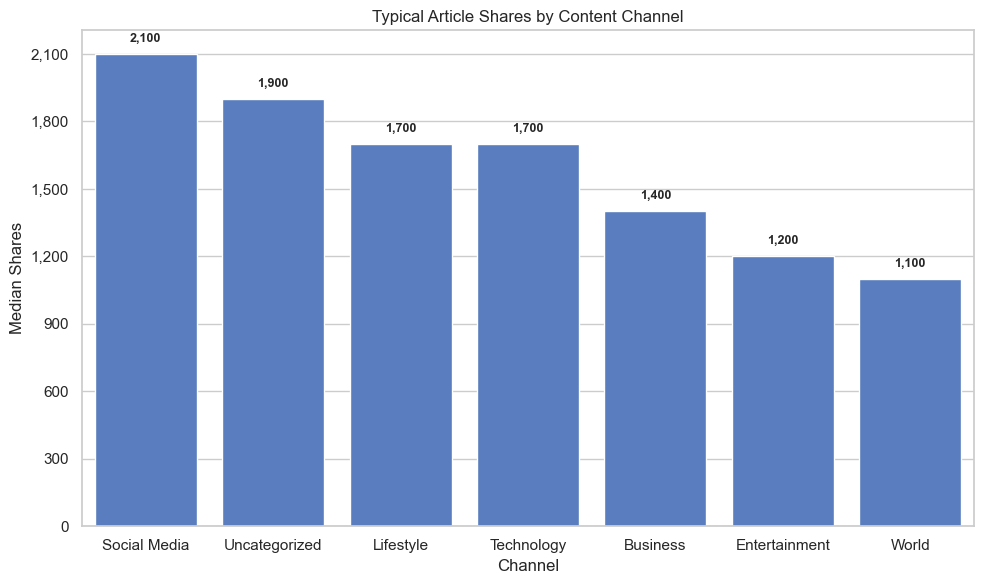

In [25]:
order = channel_summary.index.tolist()

plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, x="channel", y="shares", estimator=np.median, order=order, ci=None)

# Title and labels
ax.set_title("Typical Article Shares by Content Channel")
ax.set_xlabel("Channel")
ax.set_ylabel("Median Shares")

# Choose y-ticks
max_val = df.groupby("channel")["shares"].median().max()
yticks = np.linspace(0, max_val, 8)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(t):,}" for t in yticks])

# --- Add data labels ---
medians = df.groupby("channel")["shares"].median().reindex(order)
for i, (cat, val) in enumerate(medians.items()):
    ax.text(i, val + (0.02 * max_val), f"{int(val):,}", 
            ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\83287165.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t):,}" for t in yticks])


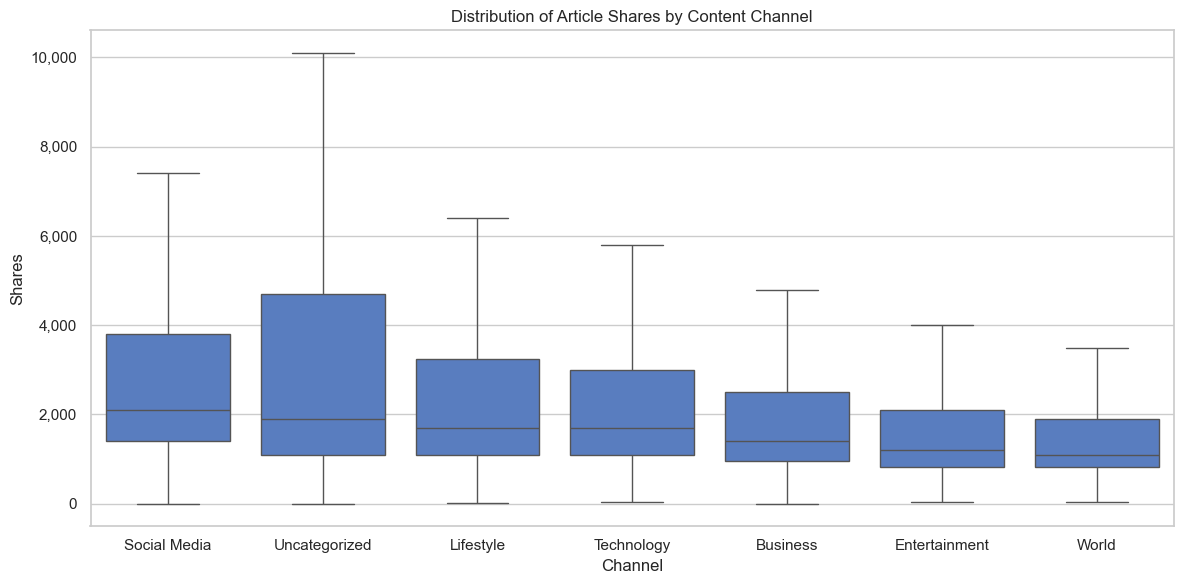

In [26]:
plt.figure(figsize=(12,6))
ax = sns.boxplot(
    data=df, 
    x="channel", 
    y="shares", 
    order=order,       
    showfliers=False    # hide extreme outliers so boxes are easier to read
)

ax.set_title("Distribution of Article Shares by Content Channel")
ax.set_xlabel("Channel")
ax.set_ylabel("Shares")

# Format y-ticks with commas
yticks = ax.get_yticks()
ax.set_yticklabels([f"{int(t):,}" for t in yticks])

plt.tight_layout()
plt.show()


In [27]:
def boxplot_stats(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    
    # Tukey's fences (1.5× IQR rule)
    lower_whisker = x[x >= (q1 - 1.5 * iqr)].min()
    upper_whisker = x[x <= (q3 + 1.5 * iqr)].max()
    
    return pd.Series({
        "Q0 (whisker)": lower_whisker,
        "Q1 (25th)": q1,
        "Median (Q2)": x.median(),
        "Q3 (75th)": q3,
        "Q4 (whisker)": upper_whisker,
        "Min": x.min(),
        "Max": x.max()
    })

# Apply per channel
channel_box_stats = df.groupby("channel")["shares"].apply(boxplot_stats).unstack()

# Format with commas
channel_box_stats = channel_box_stats.applymap(lambda v: f"{int(v):,}")

channel_box_stats


C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\2038349098.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  channel_box_stats = channel_box_stats.applymap(lambda v: f"{int(v):,}")


,Q0 (whisker),Q1 (25th),Median (Q2),Q3 (75th),Q4 (whisker),Min,Max
channel,,,,,,,
Business,1,952,"1,400","2,500","4,800",1,"690,400"
Entertainment,47,833,"1,200","2,100","4,000",47,"210,300"
Lifestyle,28,"1,100","1,700","3,250","6,400",28,"208,300"
Social Media,5,"1,400","2,100","3,800","7,400",5,"122,800"
Technology,36,"1,100","1,700","3,000","5,800",36,"663,600"
Uncategorized,4,"1,100","1,900","4,700","10,100",4,"843,300"
World,35,827,"1,100","1,900","3,500",35,"284,700"


We found that Social Media articles drive the highest engagement, with a median of ~2,100 shares and strong viral upside. Lifestyle and Technology follow closely, offering reliable performance. Business and World articles, while more stable, tend to generate lower engagement. This suggests editorial resources should be weighted toward Social Media, Lifestyle, and Tech if the goal is maximizing reach.

### Step 6: **Does article length affect popularity?**

Goal:

Detemine if there's a "sweet spot" in article length that maximizes shares.

In [31]:
print("\n---Statistical description on `n_tokens_title`---\n")
df["n_tokens_title"].describe()


---Statistical description on `n_tokens_title`---



count    39644.000000
mean        10.398749
std          2.114037
min          2.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         23.000000
Name: n_tokens_title, dtype: float64

In [32]:
print("\n---Statistical description on `n_tookens_content`---\n")
df["n_tokens_content"].describe()


---Statistical description on `n_tookens_content`---



count    39644.000000
mean       546.514731
std        471.107508
min          0.000000
25%        246.000000
50%        409.000000
75%        716.000000
max       8474.000000
Name: n_tokens_content, dtype: float64

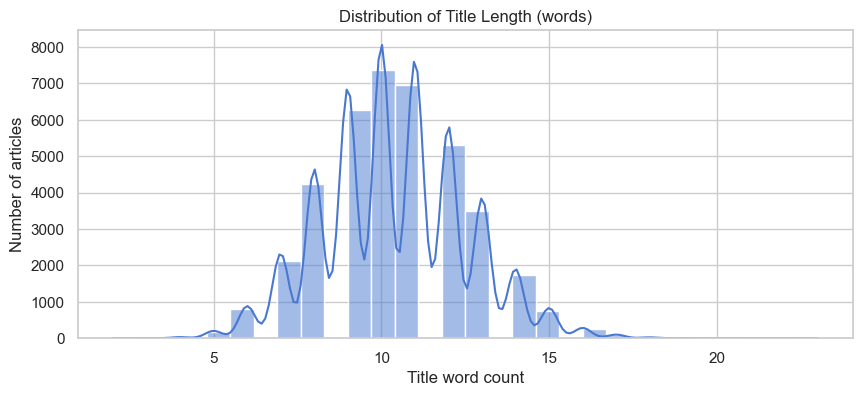

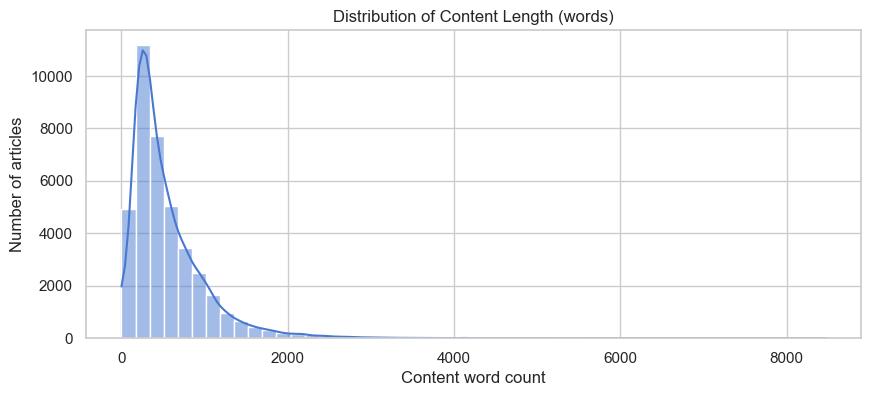

In [33]:
plt.figure(figsize=(10,4))
sns.histplot(df["n_tokens_title"], bins=30, kde=True)
plt.title("Distribution of Title Length (words)")
plt.xlabel("Title word count")
plt.ylabel("Number of articles")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df["n_tokens_content"], bins=50, kde=True)
plt.title("Distribution of Content Length (words)")
plt.xlabel("Content word count")
plt.ylabel("Number of articles")
plt.show()

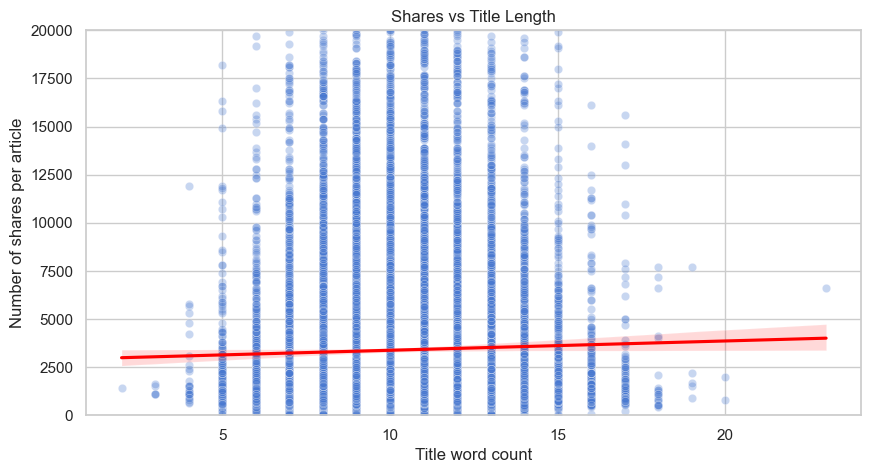

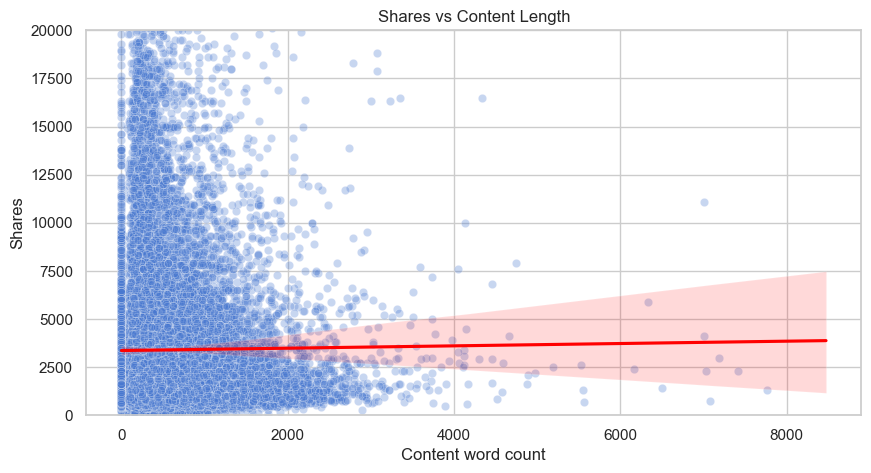

In [34]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="n_tokens_title", y="shares", alpha=0.3)
sns.regplot(data=df, x="n_tokens_title", y="shares", scatter=False, color="red")
plt.title("Shares vs Title Length")
plt.xlabel("Title word count")
plt.ylabel("Number of shares per article")
plt.ylim(0, 20000)
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="n_tokens_content", y="shares", alpha=0.3)
sns.regplot(data=df, x="n_tokens_content", y="shares", scatter=False, color="red")
plt.title("Shares vs Content Length")
plt.xlabel("Content word count")
plt.ylabel("Shares")
plt.ylim(0, 20000)  # cap for readability
plt.show()

In [35]:
df["n_tokens_title"].describe()

count    39644.000000
mean        10.398749
std          2.114037
min          2.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         23.000000
Name: n_tokens_title, dtype: float64

In [36]:
df["n_tokens_content"].describe()

count    39644.000000
mean       546.514731
std        471.107508
min          0.000000
25%        246.000000
50%        409.000000
75%        716.000000
max       8474.000000
Name: n_tokens_content, dtype: float64

In [37]:
# Title bins
df["title_len_bin"] = pd.cut(
    df["n_tokens_title"], 
    bins=[0,5,10,15,20,60], 
    labels=["0–5","6–8","9–12","13–15","16+"]
)

# Content bins (convert to approx read time at 200 wpm)
df["read_time_min"] = df["n_tokens_content"] / 200
df["content_len_bin"] = pd.cut(
    df["read_time_min"], 
    bins=[0,2,5,10,20,60], 
    labels=["0–2 min","3–5 min","6–10 min","11–20 min","20+ min"]
)


In [38]:
title_summary = df.groupby("title_len_bin")["shares"].median()
content_summary = df.groupby("content_len_bin")["shares"].median()

print("Median shares by title length bin:\n", title_summary)
print("\nMedian shares by content length bin:\n", content_summary)


Median shares by title length bin:
 title_len_bin
0–5      1600.0
6–8      1500.0
9–12     1400.0
13–15    1450.0
16+      6600.0
Name: shares, dtype: float64

Median shares by content length bin:
 content_len_bin
0–2 min      1400.0
3–5 min      1400.0
6–10 min     1600.0
11–20 min    1800.0
20+ min      2650.0
Name: shares, dtype: float64


C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\2809599325.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  title_summary = df.groupby("title_len_bin")["shares"].median()
C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\2809599325.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  content_summary = df.groupby("content_len_bin")["shares"].median()


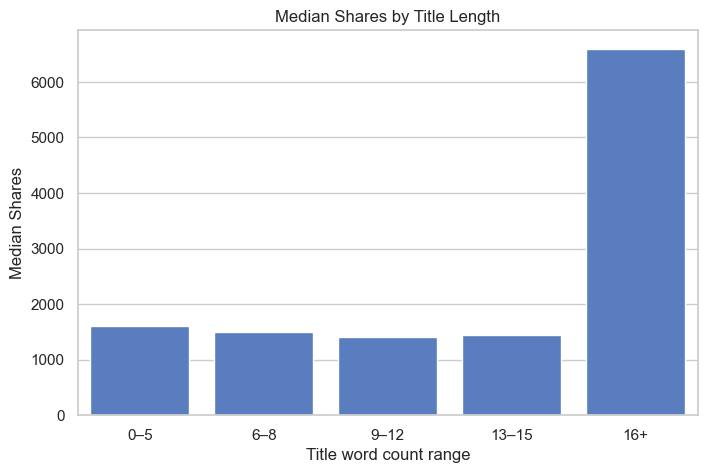

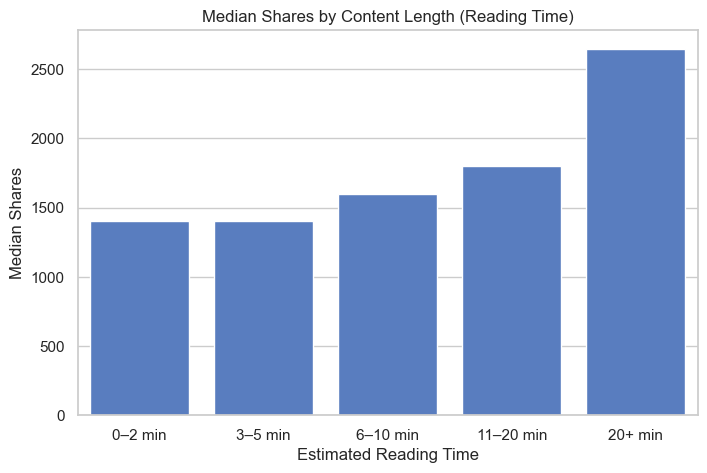

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(x=title_summary.index, y=title_summary.values)
plt.title("Median Shares by Title Length")
plt.xlabel("Title word count range")
plt.ylabel("Median Shares")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=content_summary.index, y=content_summary.values)
plt.title("Median Shares by Content Length (Reading Time)")
plt.xlabel("Estimated Reading Time")
plt.ylabel("Median Shares")
plt.show()


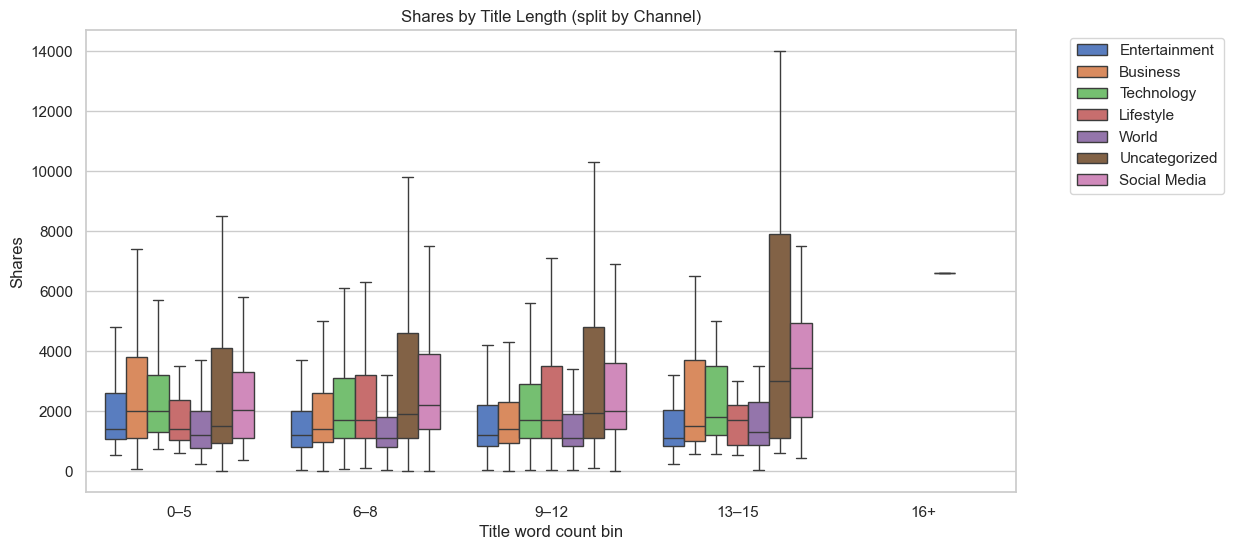

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df, 
    x="title_len_bin", 
    y="shares", 
    hue="channel", 
    showfliers=False
)
plt.title("Shares by Title Length (split by Channel)")
plt.ylabel("Shares")
plt.xlabel("Title word count bin")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()


### **Step 7 — Q3: How do timing and recency matter?**

In [42]:
print("\n---Statistical Summary For `timedelta`---\n")
df["timedelta"].describe()


---Statistical Summary For `timedelta`---



count    39644.000000
mean       354.530471
std        214.163767
min          8.000000
25%        164.000000
50%        339.000000
75%        542.000000
max        731.000000
Name: timedelta, dtype: float64

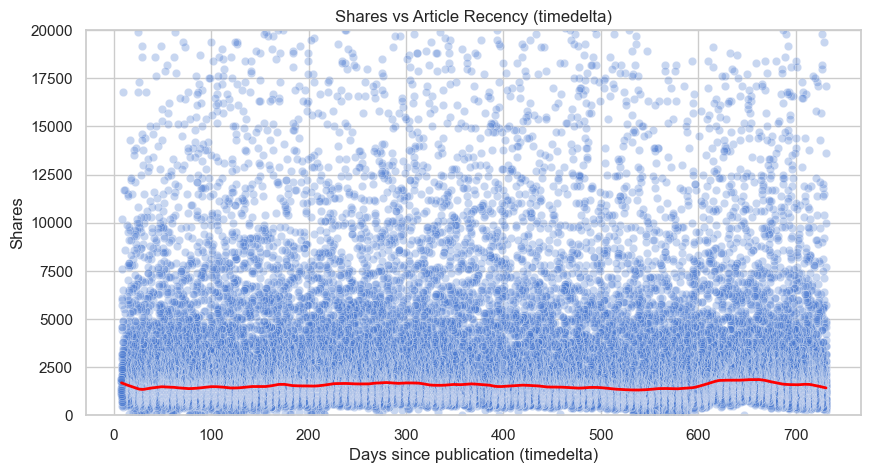

In [43]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="timedelta", y="shares", alpha=0.3)
from statsmodels.nonparametric.smoothers_lowess import lowess
lowess_smoothed = lowess(df["shares"], df["timedelta"], frac=0.05)
plt.plot(lowess_smoothed[:,0], lowess_smoothed[:,1], color="red", linewidth=2)

plt.title("Shares vs Article Recency (timedelta)")
plt.xlabel("Days since publication (timedelta)")
plt.ylabel("Shares")
plt.ylim(0, 20000)
plt.show()

In [44]:
weekday_cols = [c for c in df.columns if c.startswith("weekday_is_")]

weekday_map = {
    "weekday_is_monday": "Monday",
    "weekday_is_tuesday": "Tuesday",
    "weekday_is_wednesday": "Wednesday",
    "weekday_is_thursday": "Thursday",
    "weekday_is_friday": "Friday",
    "weekday_is_saturday": "Saturday",
    "weekday_is_sunday": "Sunday"
}

weekday_df = df[weekday_cols]
df["weekday"] = weekday_df.idxmax(axis=1).map(weekday_map)

In [45]:
weekday_summary = (
    df.groupby("weekday")["shares"]
    .median()
    .sort_values(ascending=False)
)

print("Median shares by weekday:\n", weekday_summary)

Median shares by weekday:
 weekday
Saturday     2000.0
Sunday       1900.0
Friday       1500.0
Monday       1400.0
Thursday     1400.0
Tuesday      1300.0
Wednesday    1300.0
Name: shares, dtype: float64


C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\3177501558.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="weekday", y="shares", estimator=np.median, order=weekday_summary.index, ci=None)


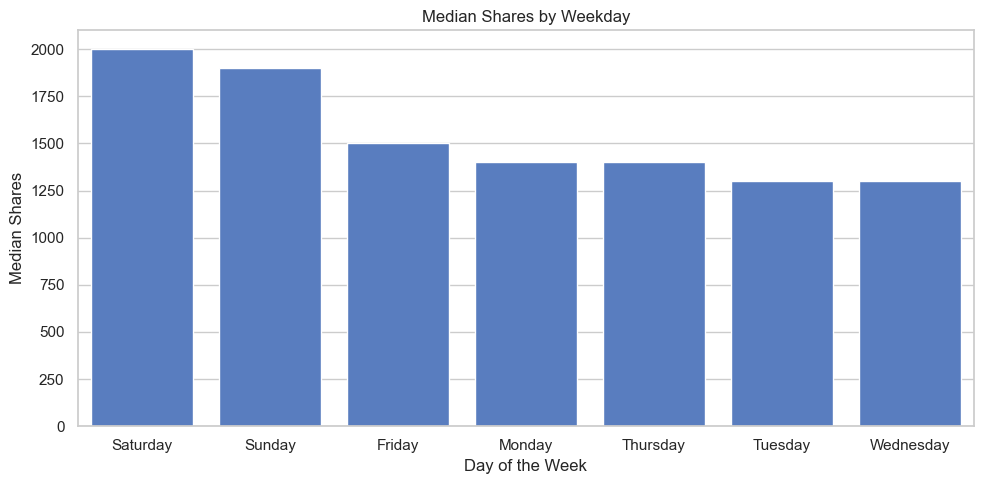

In [46]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="weekday", y="shares", estimator=np.median, order=weekday_summary.index, ci=None)
plt.title("Median Shares by Weekday")
plt.xlabel("Day of the Week")
plt.ylabel("Median Shares")
plt.tight_layout()
plt.show()

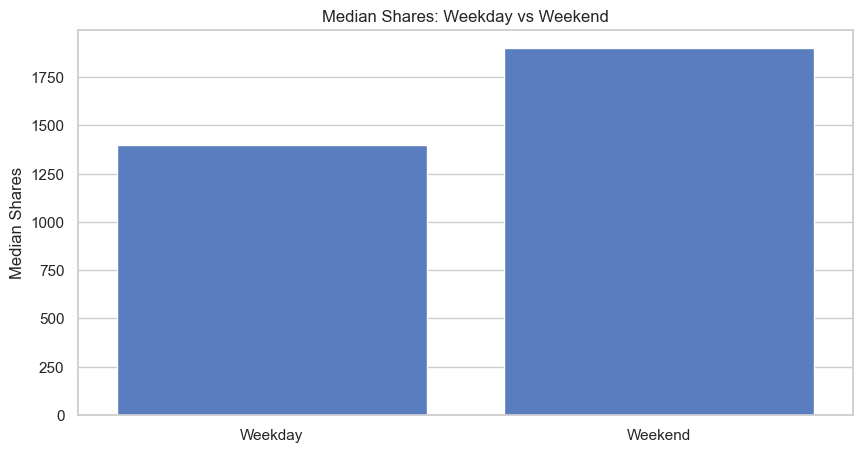

In [47]:
# Dataset already has is_weekend column
weekend_summary = df.groupby("is_weekend")["shares"].median()
weekend_summary.index = ["Weekday","Weekend"]

plt.figure(figsize=(10,5))
sns.barplot(x=weekend_summary.index, y=weekend_summary.values)
plt.title("Median Shares: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("Median Shares")
plt.show()


### **Step 8 — Q4: What role do visuals and links play?**

In [49]:
visual_cols = ["num_imgs", "num_videos", "num_hrefs", "num_self_hrefs"]

df[visual_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_imgs,39644.0,4.544143,8.309434,0.0,1.0,1.0,4.0,128.0
num_videos,39644.0,1.249874,4.107855,0.0,0.0,0.0,1.0,91.0
num_hrefs,39644.0,10.883690,11.332017,0.0,4.0,8.0,14.0,304.0
num_self_hrefs,39644.0,3.293638,3.855141,0.0,1.0,3.0,4.0,116.0


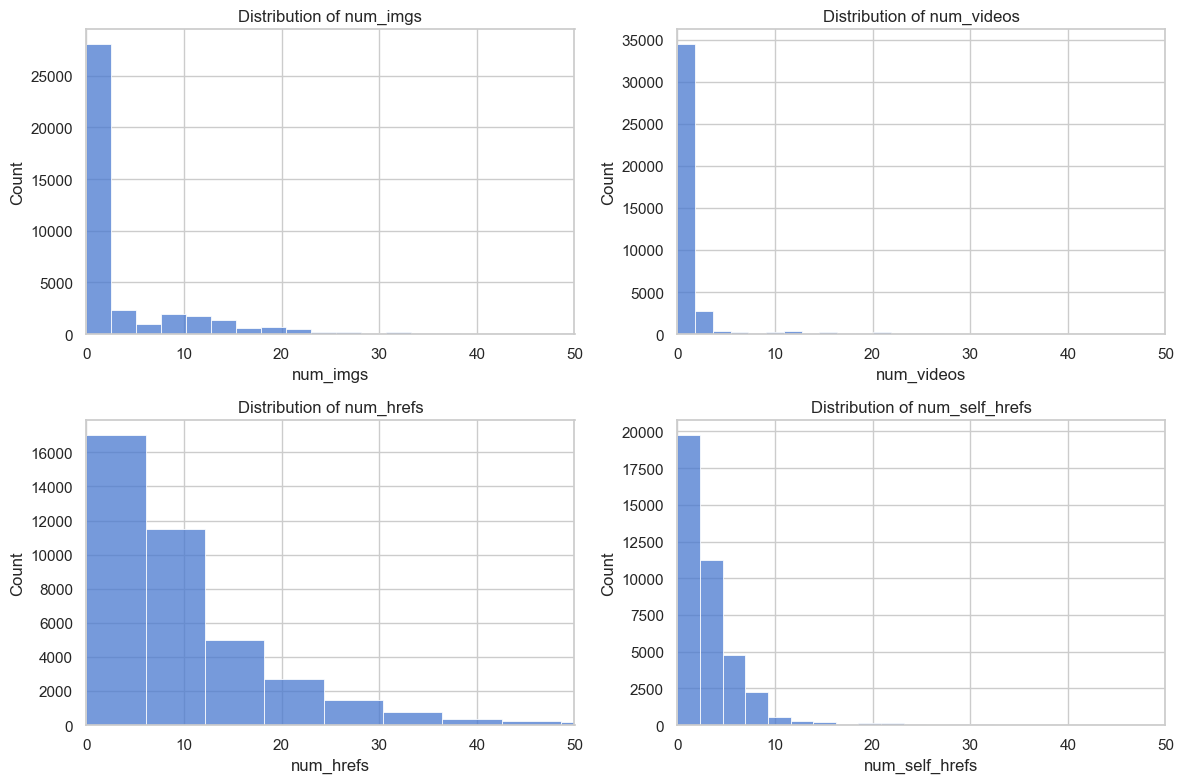

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for ax, col in zip(axes.flat, visual_cols):
    sns.histplot(df[col], bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlim(0, 50)
plt.tight_layout()
plt.show()

In [51]:
for col in visual_cols:
    corr = df[col].corr(df["shares"], method="spearman")
    print(f"Spearman correlation between {col} and shares: {corr:.3f}")

Spearman correlation between num_imgs and shares: 0.083
Spearman correlation between num_videos and shares: 0.049
Spearman correlation between num_hrefs and shares: 0.090
Spearman correlation between num_self_hrefs and shares: 0.038


In [52]:
# Define bins
df["img_bin"] = pd.cut(df["num_imgs"], bins=[-1,0,2,5,10,100],
                       labels=["0","1–2","3–5","6–10","10+"])

df["video_bin"] = pd.cut(df["num_videos"], bins=[-1,0,1,3,10,100],
                         labels=["0","1","2–3","4–10","10+"])

df["href_bin"] = pd.cut(df["num_hrefs"], bins=[-1,5,10,20,40,1000],
                        labels=["0–5","6–10","11–20","21–40","40+"])

df["self_href_bin"] = pd.cut(df["num_self_hrefs"], bins=[-1,0,2,5,10,100],
                             labels=["0","1–2","3–5","6–10","10+"])


C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\2124441582.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="img_bin", y="shares", estimator=np.median, ax=axes[0,0], ci=None)
C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\2124441582.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="video_bin", y="shares", estimator=np.median, ax=axes[0,1], ci=None)
C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\2124441582.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="href_bin", y="shares", estimator=np.median, ax=axes[1,0], ci=None)
C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\2124441582.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="self_href_bin", y="shares", estim

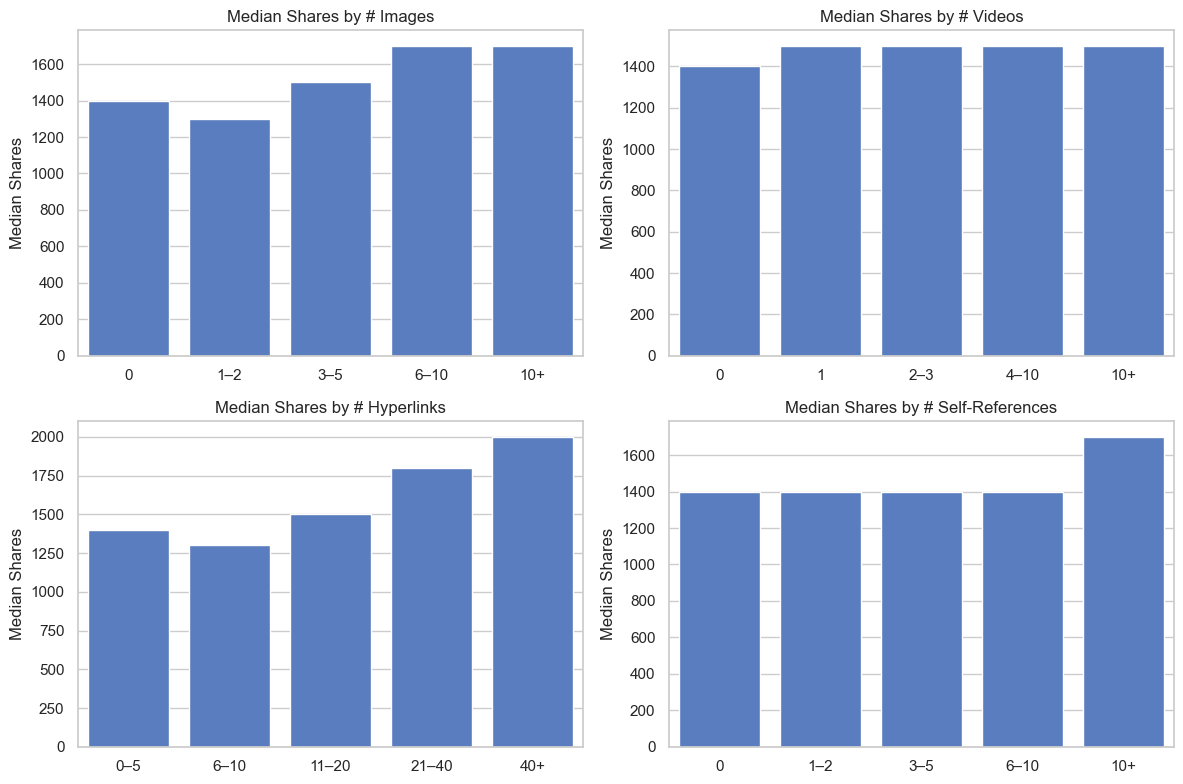

In [53]:
# Plot median shares for each bin
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.barplot(data=df, x="img_bin", y="shares", estimator=np.median, ax=axes[0,0], ci=None)
axes[0,0].set_title("Median Shares by # Images")

sns.barplot(data=df, x="video_bin", y="shares", estimator=np.median, ax=axes[0,1], ci=None)
axes[0,1].set_title("Median Shares by # Videos")

sns.barplot(data=df, x="href_bin", y="shares", estimator=np.median, ax=axes[1,0], ci=None)
axes[1,0].set_title("Median Shares by # Hyperlinks")

sns.barplot(data=df, x="self_href_bin", y="shares", estimator=np.median, ax=axes[1,1], ci=None)
axes[1,1].set_title("Median Shares by # Self-References")

for ax in axes.flat:
    ax.set_ylabel("Median Shares")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


### Step 9 — Q5: Do sentiment and keywords influence sharing?

              count         mean          std  min          25%          50%          75%            max
kw_min_avg  39644.0  1117.146610  1137.456951 -1.0     0.000000  1023.635611  2056.781032    3613.039819
kw_max_avg  39644.0  5657.211151  6098.871957  0.0  3562.101631  4355.688836  6019.953968  298400.000000
kw_avg_avg  39644.0  3135.858639  1318.150397  0.0  2382.448566  2870.074878  3600.229564   43567.659946
Spearman correlation between kw_min_avg and shares: 0.103
Spearman correlation between kw_max_avg and shares: 0.223
Spearman correlation between kw_avg_avg and shares: 0.256


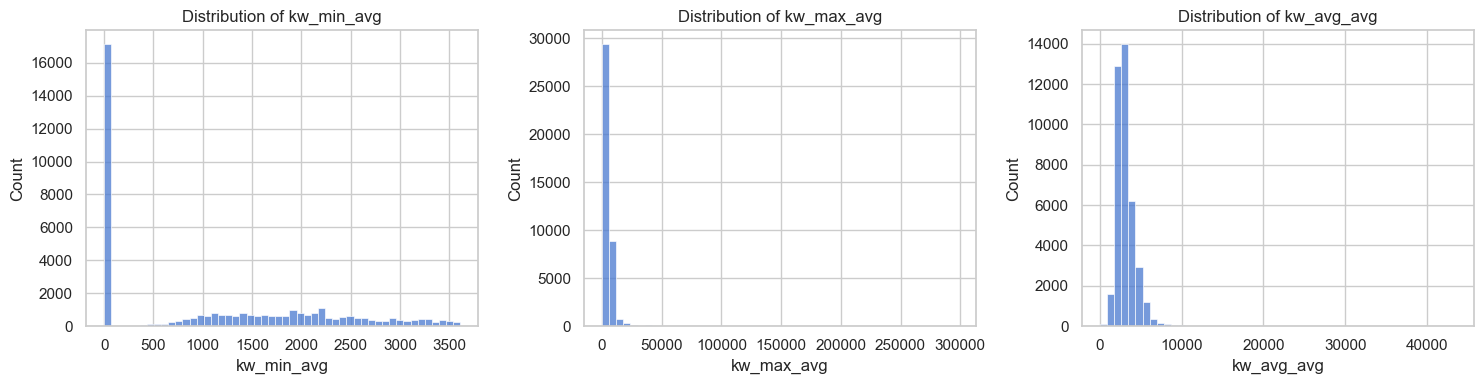

In [55]:
kw_cols = ["kw_min_avg", "kw_max_avg", "kw_avg_avg"]

# Summary stats
print(df[kw_cols].describe().T)

# Correlations with shares
for col in kw_cols:
    corr = df[col].corr(df["shares"], method="spearman")
    print(f"Spearman correlation between {col} and shares: {corr:.3f}")

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, kw_cols):
    sns.histplot(df[col], bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\4040264200.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)


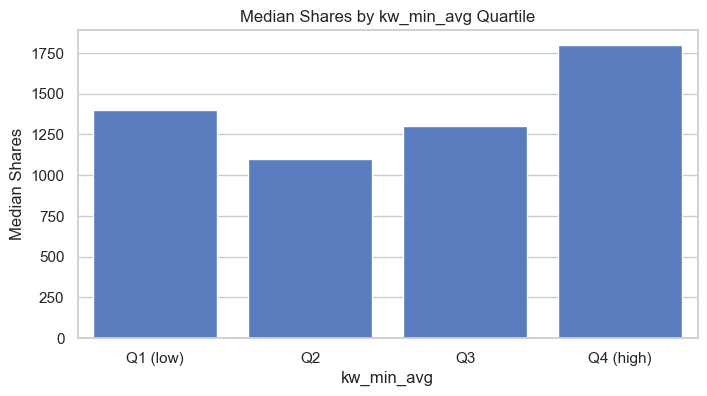

C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\4040264200.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)


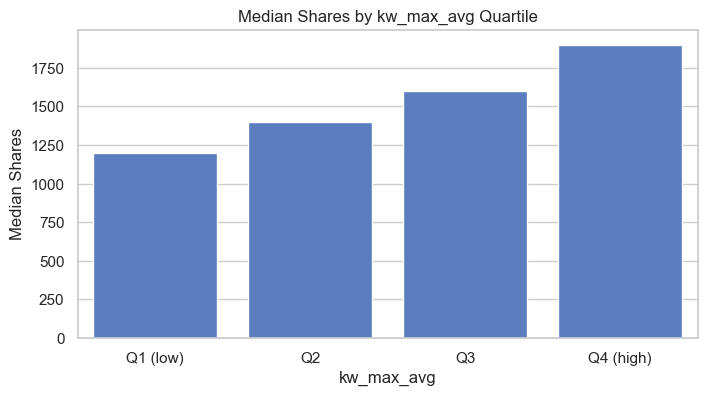

C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\4040264200.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)


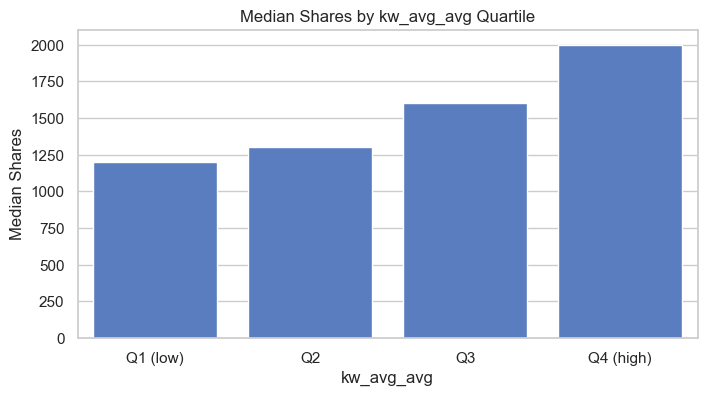

In [56]:
for col in kw_cols:
    df[f"{col}_bin"] = pd.qcut(df[col], 4, labels=["Q1 (low)","Q2","Q3","Q4 (high)"])

    plt.figure(figsize=(8,4))
    sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)
    plt.title(f"Median Shares by {col} Quartile")
    plt.ylabel("Median Shares")
    plt.xlabel(col)
    plt.show()


C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\3703672082.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)


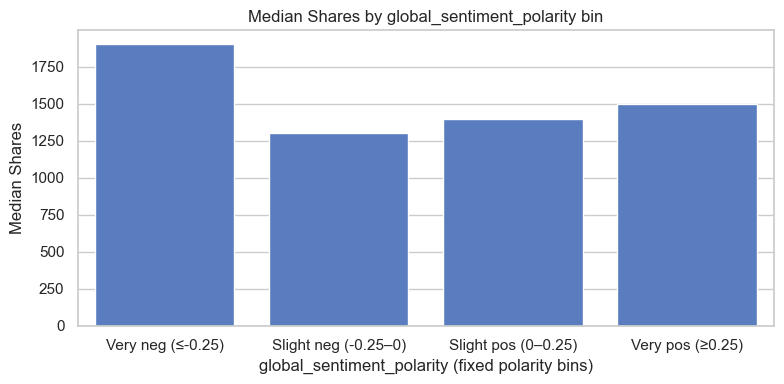

C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\3703672082.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)


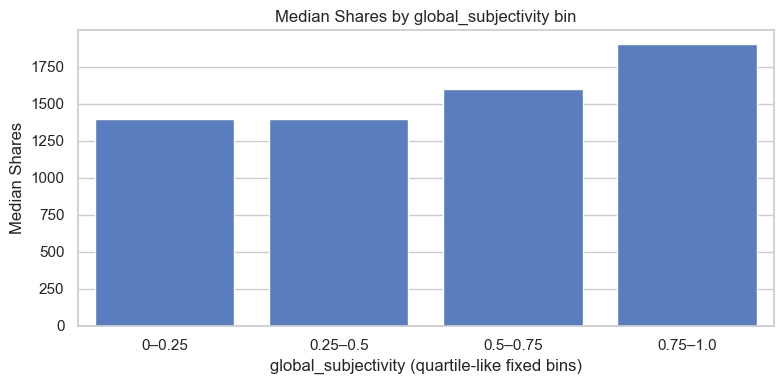

C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\3703672082.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)


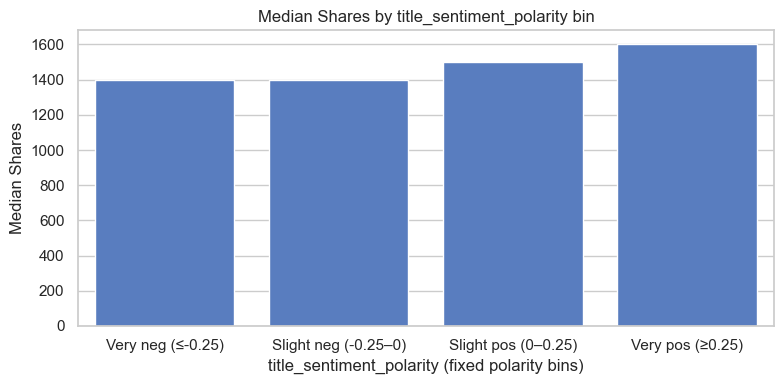

C:\Users\Christopher\AppData\Local\Temp\ipykernel_2096\3703672082.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)


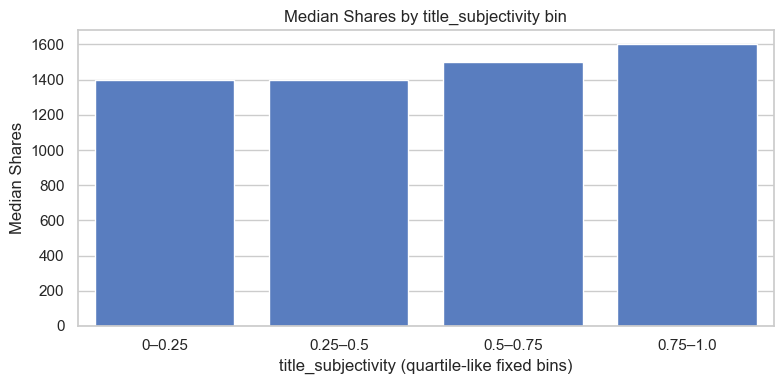

In [57]:
# Polarity: [-1, 1], Subjectivity: [0, 1]
sentiment_cols = [
    "global_sentiment_polarity",
    "global_subjectivity",
    "title_sentiment_polarity",
    "title_subjectivity",
]

for col in sentiment_cols:
    if "subjectivity" in col:
        bins   = [0.0, 0.25, 0.50, 0.75, 1.0]
        labels = ["0–0.25", "0.25–0.5", "0.5–0.75", "0.75–1.0"]
        s = df[col].clip(0, 1)  # safety
        xlabel = f"{col} (quartile-like fixed bins)"
    else:
        bins   = [-1.0, -0.25, 0.0, 0.25, 1.0]
        labels = ["Very neg (≤-0.25)", "Slight neg (-0.25–0)",
                  "Slight pos (0–0.25)", "Very pos (≥0.25)"]
        s = df[col].clip(-1, 1)  # safety
        xlabel = f"{col} (fixed polarity bins)"

    df[f"{col}_bin"] = pd.cut(s, bins=bins, labels=labels, include_lowest=True)

    plt.figure(figsize=(8,4))
    sns.barplot(data=df, x=f"{col}_bin", y="shares", estimator=np.median, ci=None)
    plt.title(f"Median Shares by {col} bin")
    plt.ylabel("Median Shares")
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()


### **Q6: Can We Predict Article Popularity Before Publication?**

In [103]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [105]:
features = [
    "n_tokens_title", "n_tokens_content",
    "num_imgs", "num_videos", "num_hrefs", "num_self_hrefs",
    "kw_avg_avg", "kw_max_avg",
    "global_sentiment_polarity", "global_subjectivity",
    "title_sentiment_polarity", "title_subjectivity",
    "channel", "weekday", "is_weekend"
]

target = "shares"


In [107]:
df_model = df[features + [target]].dropna().copy()


In [109]:
numeric_features = [
    "n_tokens_title","n_tokens_content","num_imgs","num_videos",
    "num_hrefs","num_self_hrefs","kw_avg_avg","kw_max_avg",
    "global_sentiment_polarity","global_subjectivity",
    "title_sentiment_polarity","title_subjectivity","is_weekend"
]
categorical_features = ["channel","weekday"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


In [111]:
X = df_model[features]
y = df_model["shares"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

reg_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])

reg_pipeline.fit(X_train, y_train)
y_pred = reg_pipeline.predict(X_test)


In [113]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R²: 0.019398150302651462
MAE: 3030.3893656358164
RMSE: 10691.587576696087


In [115]:
median_shares = df_model["shares"].median()
df_model["is_viral"] = (df_model["shares"] > median_shares).astype(int)


In [117]:
X = df_model[features]
y = df_model["is_viral"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [119]:
clf_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)
y_prob = clf_pipeline.predict_proba(X_test)[:,1]


In [121]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6423166178993038
F1: 0.6343476018566271
ROC-AUC: 0.6862486758070094
Confusion Matrix:
 [[3291 1730]
 [1815 3075]]


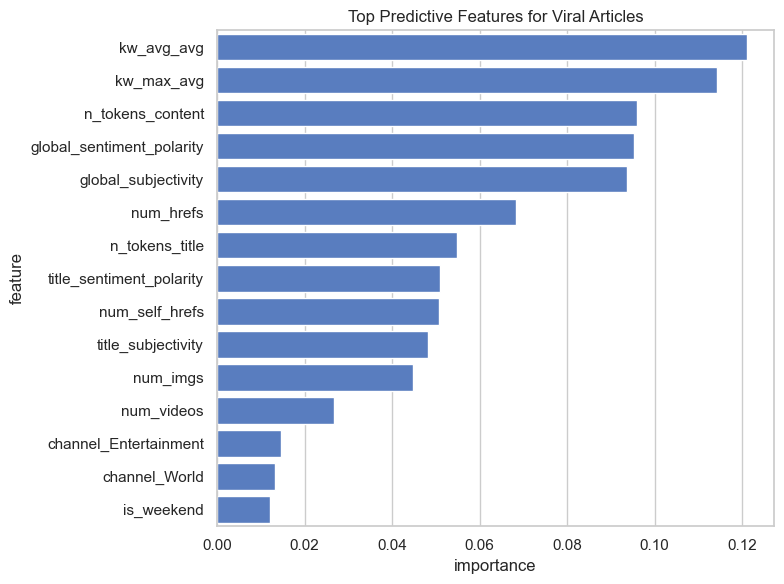

In [123]:
rf_clf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])
rf_clf.fit(X_train, y_train)

# Get feature importances
feature_names = (
    numeric_features
    + list(rf_clf.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_features))
)
importances = rf_clf.named_steps["model"].feature_importances_
feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(y="feature", x="importance", data=feat_imp.head(15))
plt.title("Top Predictive Features for Viral Articles")
plt.tight_layout()
plt.show()
